In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# ── 1. Vectors & matrices ──────────────────────────
v1 = np.array([1, 2, 3])          # vector
v2 = np.array([4, 5, 6])

W = np.random.randn(3, 4)         # weight matrix (3 inputs, 4 outputs)
x = np.random.randn(3)            # input vector

print("W shape:", W.shape)
print("x shape:", x.shape)


W shape: (3, 4)
x shape: (3,)


In [3]:
# ── 2. Dot product & matmul ────────────────────────
dot = np.dot(v1, v2)              # scalar
print("Dot product:", dot)        # 32

out = W.T @ x                     # shape (4,) — forward pass of one layer!
print("Layer output shape:", out.shape)

Dot product: 32
Layer output shape: (4,)


In [4]:
# ── 3. Implementing derivatives ───────────────────
def numerical_derivative(f, x, h=1e-5):
    return (f(x + h) - f(x - h)) / (2 * h)

f = lambda x: x**2
print("Derivative of x^2 at x=3:", numerical_derivative(f, 3))  # ≈ 6.0

Derivative of x^2 at x=3: 6.000000000039306


In [5]:
# ── 4. Statistics ─────────────────────────────────
data = np.random.randn(1000)      # 1000 random numbers

print("Mean:    ", np.mean(data).round(3))
print("Variance:", np.var(data).round(3))
print("Std Dev: ", np.std(data).round(3))

# Normalize (what BatchNorm does internally)
normalized = (data - np.mean(data)) / np.std(data)
print("After norm — mean:", np.mean(normalized).round(3),
      "std:", np.std(normalized).round(3))  # ~0.0, ~1.0

Mean:     -0.021
Variance: 1.011
Std Dev:  1.005
After norm — mean: 0.0 std: 1.0


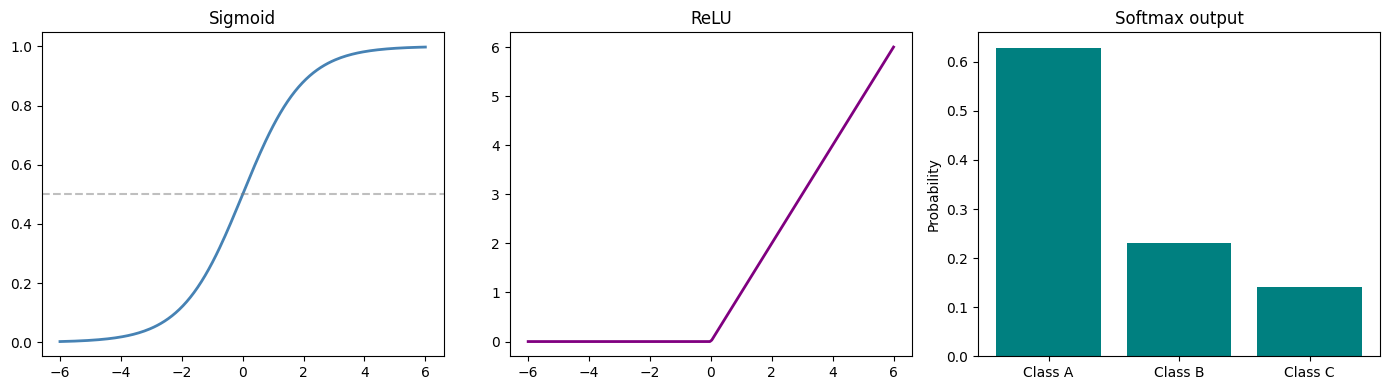

Softmax probs: [0.629 0.231 0.14 ]


In [6]:
# ── 5. Activation functions from scratch ──────────
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def softmax(x):
    e_x = np.exp(x - np.max(x))   # subtract max for numerical stability
    return e_x / e_x.sum()

def relu(x):
    return np.maximum(0, x)

# Plot all three
x_range = np.linspace(-6, 6, 200)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(x_range, sigmoid(x_range), color='steelblue', lw=2)
axes[0].set_title('Sigmoid')
axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.5)

axes[1].plot(x_range, relu(x_range), color='purple', lw=2)
axes[1].set_title('ReLU')

logits = np.array([2.0, 1.0, 0.5])
probs = softmax(logits)
axes[2].bar(['Class A','Class B','Class C'], probs, color='teal')
axes[2].set_title('Softmax output')
axes[2].set_ylabel('Probability')

plt.tight_layout()
plt.show()
print("Softmax probs:", probs.round(3))  # sum = 1.0